# Generated qLDLC decoding

This notebook loads one generated qLDLC artifact by name, prepares the decoding experiment, and runs a tiny smoke decode. The artifact loading hides the JLD2 conversion and matrix setup details.

In [1]:
using Random

qldlc_helper = normpath(joinpath(@__DIR__, "..", "experiments", "decode_qldlc_codes.jl"))
isfile(qldlc_helper) || (qldlc_helper = joinpath(pwd(), "experiments", "decode_qldlc_codes.jl"))
include(qldlc_helper);

Random.seed!(1);

function is_not_logical_error(logical_check, residual; atol = 1e-5)
    logical_coordinates = logical_check' * residual
    return all(abs(x - round(x)) < atol for x in logical_coordinates)
end;



SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Choose a generated qLDLC by filename stem. The helper also accepts a full path or a `.jld2` filename.

In [2]:
code_name = "reduced_ldlc_gkp_n_17_30"

qec_problem = load_qldlc_generated_code(code_name);

display(qec_problem.H)


34×34 Matrix{Float64}:
      0.0            0.0         …       0.0              0.0
      0.0            0.0                 0.0              0.0
      0.0            0.0                 0.0              0.0
      0.0            0.0                 0.0              0.0
      0.0            0.0                 0.0              4.0
      0.0            0.0         …       0.0              0.0
      0.0            0.0                 0.0             59.0
      2.0            0.0               -77.0            483.0
 -19817.0           -2.0            -19745.0          80339.0
     -1.7881e8     220.0                -1.77659e8        7.23883e8
      ⋮                          ⋱                   
 -70458.0            0.0         …  -70008.0         285245.0
      1.04051e7     -1.0                 1.03382e7       -4.21237e7
     -2.95468e10  3336.0                -2.93568e10       1.19616e11
     -7.32877e13     7.38812e6          -7.28163e13       2.96695e14
      1.39082e22    -1.40208e

The prepared object contains the decoding problem, run parameters, artifact metadata, and the concrete `H` and `G` matrices.

In [3]:
H = qec_problem.H;
G = qec_problem.G;
logical_check = qec_problem.logical_check;



noise_std = 0.4 / sqrt(2 * pi)
max_iter = 1_000
decoder = "nearest"

error_vector = sample_error(noise_std, size(H, 2));
received = copy(error_vector);

tanner_graph = initialize_tanner_graph(H);
bp_estimate = run_belief_propagation!(
    tanner_graph,
    received,
    noise_std,
    max_iter,
    decoder;
);

decoded_integer_correction = hard_decision(bp_estimate, H);

correction = received - G * decoded_integer_correction;
residual = error_vector - correction;

println("H * bp_estimate = ", H * bp_estimate)

logical_success = is_not_logical_error(logical_check, residual)

InexactError: InexactError: Int64(-5.285689450729625e23)

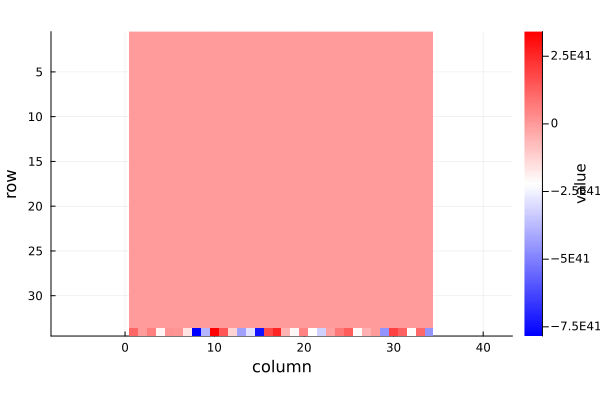

In [6]:
using Plots
my_gradient = cgrad([:blue, :white, :red], [-2, 0.0, 2.0])
p = heatmap(
        H;
        aspect_ratio=:equal,
        color=my_gradient,
        xlabel="column",
        ylabel="row",
        yflip=true,
        colorbar_title="value",
    )

